# Add to the path

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [48]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import optim
import time

import tltorch
from Utils.Reshape import reshape

from torch import einsum
from sklearn.decomposition import PCA

In [67]:
pca.fit_transform(x_true[0]).shape

(10, 1)

# Synthetic Data

In [62]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is : {device}')

x_true = np.linspace(-100, 100, 10000).reshape(100,10,10)
noise = np.random.normal(0, 1, 10000).reshape(100,10,10)
x = x_true + noise
x = torch.tensor(x, dtype=torch.float32, device=device)

W = np.random.normal(0, 1, 200).reshape(10,10,2)
W = torch.tensor(W, dtype=torch.float32, device=device)
y_true = torch.einsum('bqw , qwz -> bz', torch.tensor(x_true, dtype=torch.float32, device=device), W)

_, labels = torch.max(y_true, 1)


pca = PCA(n_components=1)
x_1d = np.zeros((100,1))
for i in range(100):
    x_1d[i] = pca.fit_transform(x_true[i])

plt.figure(figsize=(6, 6))
plt.scatter(x_1d, labels.cpu().numpy())
plt.scatter(x,y_true)
plt.axis('off')
plt.show()

device is : cuda


ValueError: could not broadcast input array from shape (10,1) into shape (1,)

device is : cuda


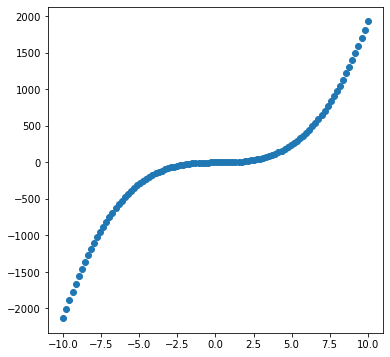

In [8]:


x_true = np.linspace(-10, 10, 100)
y_true = 2 * x_true**3 + 3*x_true - x_true**2

noise = np.random.normal(0, 1, 100)
x = x_true + noise

plt.figure(figsize=(6, 6))
plt.scatter(x_true, y_true)
# plt.scatter(x,y_true)
# plt.axis('off')
plt.show()

x = torch.tensor(x, dtype=torch.float32, device=device)
y = torch.tensor(y_true, dtype=torch.float32, device=device)


# Basic Linear Model

Epoch [1/100], Loss: 639666.0000
Epoch [2/100], Loss: 164827.1094
Epoch [3/100], Loss: 119633.3906
Epoch [4/100], Loss: 115280.1406
Epoch [5/100], Loss: 114811.0781
Epoch [6/100], Loss: 114713.3984
Epoch [7/100], Loss: 114653.1406
Epoch [8/100], Loss: 114598.4297
Epoch [9/100], Loss: 114546.2109
Epoch [10/100], Loss: 114496.0781
Epoch [11/100], Loss: 114447.9375
Epoch [12/100], Loss: 114401.6953
Epoch [13/100], Loss: 114357.2812
Epoch [14/100], Loss: 114314.6406
Epoch [15/100], Loss: 114273.6797
Epoch [16/100], Loss: 114234.3359
Epoch [17/100], Loss: 114196.5547
Epoch [18/100], Loss: 114160.2891
Epoch [19/100], Loss: 114125.4375
Epoch [20/100], Loss: 114091.9609
Epoch [21/100], Loss: 114059.8203
Epoch [22/100], Loss: 114028.9609
Epoch [23/100], Loss: 113999.2969
Epoch [24/100], Loss: 113970.8281
Epoch [25/100], Loss: 113943.4766
Epoch [26/100], Loss: 113917.2266
Epoch [27/100], Loss: 113892.0078
Epoch [28/100], Loss: 113867.7812
Epoch [29/100], Loss: 113844.5078
Epoch [30/100], Loss: 1

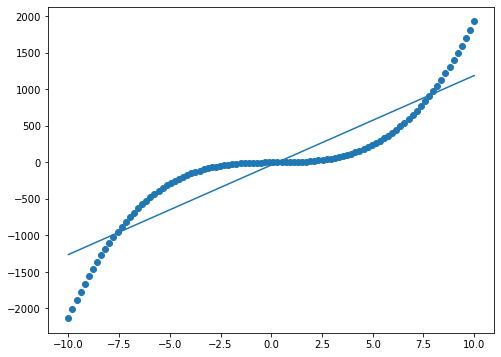

In [9]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= 1, out_features=1)
    def forward(self, x):
        x = x.reshape(-1,1)
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 100 epochs
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass
    y_pred = model(x)
    loss = criterion(y_pred, y.unsqueeze(dim = 1))
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


y_pred = model(torch.tensor(x_true, dtype=torch.float32, device=device)).detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(x_true, y_true)
plt.plot(x_true, y_pred)
plt.show()

# Basic TRL Model

In [10]:
x.shape

torch.Size([100])

Epoch [1/100], Loss: 633324.3750
Epoch [2/100], Loss: 312218752.0000
Epoch [3/100], Loss: 265860953574878439009387040873644032.0000
Epoch [4/100], Loss: inf
Epoch [5/100], Loss: inf
Epoch [6/100], Loss: nan
Epoch [7/100], Loss: nan
Epoch [8/100], Loss: nan
Epoch [9/100], Loss: nan
Epoch [10/100], Loss: nan
Epoch [11/100], Loss: nan
Epoch [12/100], Loss: nan
Epoch [13/100], Loss: nan
Epoch [14/100], Loss: nan
Epoch [15/100], Loss: nan
Epoch [16/100], Loss: nan
Epoch [17/100], Loss: nan
Epoch [18/100], Loss: nan
Epoch [19/100], Loss: nan
Epoch [20/100], Loss: nan
Epoch [21/100], Loss: nan
Epoch [22/100], Loss: nan
Epoch [23/100], Loss: nan
Epoch [24/100], Loss: nan
Epoch [25/100], Loss: nan
Epoch [26/100], Loss: nan
Epoch [27/100], Loss: nan
Epoch [28/100], Loss: nan
Epoch [29/100], Loss: nan
Epoch [30/100], Loss: nan
Epoch [31/100], Loss: nan
Epoch [32/100], Loss: nan
Epoch [33/100], Loss: nan
Epoch [34/100], Loss: nan
Epoch [35/100], Loss: nan
Epoch [36/100], Loss: nan
Epoch [37/100], 

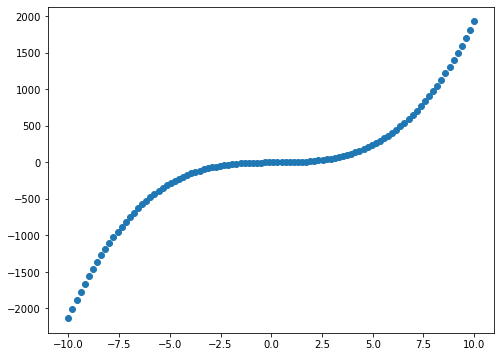

In [13]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(1), rank=(1,1), output_shape=(1), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.reshape(-1,1)
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 100 epochs
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass
    y_pred = model(x)
    loss = criterion(y_pred, y.unsqueeze(dim = 1))
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


y_pred = model(torch.tensor(x_true, dtype=torch.float32, device=device)).detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(x_true, y_true)
plt.plot(x_true, y_pred)
plt.show()

Epoch [1/5], Loss: 7332061.0
Epoch [2/5], Loss: 7011598.5
Epoch [3/5], Loss: 6706835.0
Epoch [4/5], Loss: 6417262.0
Epoch [5/5], Loss: 6142228.5
Done Training


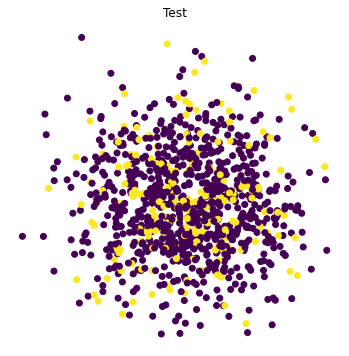

In [75]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(64,64,64), rank=(64,64,64,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic Attached Model

Epoch [1/5], Loss: 6549921.0
Epoch [2/5], Loss: 6521711.5
Epoch [3/5], Loss: 6494307.0
Epoch [4/5], Loss: 6467566.0
Epoch [5/5], Loss: 6441310.5
Done Training


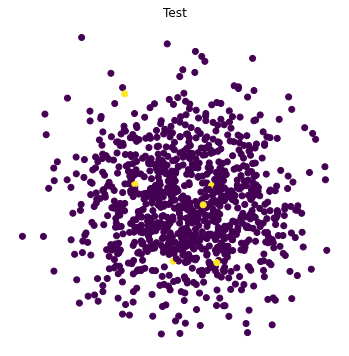

In [78]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[2,2,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(2,2,2,32,32,32), rank=(2,2,2,32,32,32,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic Compressed Model

Epoch [1/5], Loss: 6938117.0
Epoch [2/5], Loss: 6864162.5
Epoch [3/5], Loss: 6792626.5
Epoch [4/5], Loss: 6723414.0
Epoch [5/5], Loss: 6656418.0
Done Training


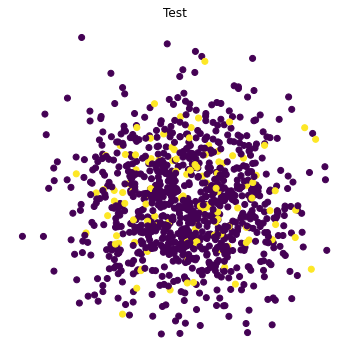

In [79]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[2,2,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(2,2,2,32,32,32), rank=(2,2,2,32,32,32,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()